# 第 5 章 · 图搜索算法

在同一校园图上，逐步观察 BFS、DFS、UCS、Greedy、A* 的**队列 / 栈 / 优先队列**如何驱动搜索，并对照 [ch5.html](../ch5.html) 动画。

配套交互演示：[章节网页](../ch5.html)

## 本节目标

- 用邻接表表示无向加权图
- 逐步执行 BFS/DFS，解释每一步 frontier 变化
- 区分「步数最少」与「代价最少」

## 1. 图与搜索问题

**顶点**表示地点（`x` 校门口、`s1` 食堂、`c1` 操场）。**边**附带步行分钟数（权重）。

**搜索**：从起点到目标找路径；算法差异在于「下一步探索哪个节点」。

**形式化**

```text
START=x, GOAL=c1
PATH = 相邻顶点序列
COST = 路径上边权之和
```

**思考** · 无向边 x↔s1 在邻接表中如何存储？

<details><summary>查看答案</summary>

两端各存一条，便于双向扩展。

</details>

## 2. 加载校园图

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "labs").exists() and (ROOT.parent / "labs").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "labs"))
sys.path.insert(0, str(ROOT / "labs" / "ch05"))
import matplotlib.pyplot as plt
from common.mpl_setup import configure_matplotlib
configure_matplotlib()
from IPython.display import display, Image
from search_algorithms import *
from common.codelens import print_frames as print_codelens
from common.viz_anim import animate_container, snapshots_from_codelens

In [2]:
graph = load_graph()

In [3]:
print('起点', graph['start'], '-> 目标', graph['goal'])

起点 x -> 目标 c1


In [4]:
display(graph_summary())

,节点,名称,h(到操场)
6,c1,操场,0
1,c2,超市,1
2,j,教学楼,4
4,s1,食堂,3
3,s2,实验楼,4
5,t,图书馆,2
0,x,校门口,7


In [5]:
display(edges_table())

,边,代价
0,x↔c2,7
1,x↔j,2
2,x↔s1,2
3,j↔s2,4
4,s2↔s1,1
5,s1↔t,3
6,s1↔c1,6
7,t↔c1,2


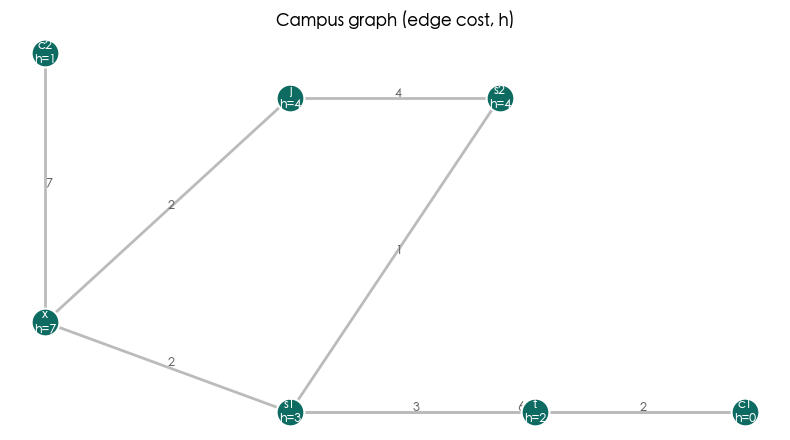

In [6]:
plot_campus(title='Campus graph (edge cost, h)')

In [7]:
display(neighbors_table('x'))

,邻居,边代价,h
0,c2,7,1
1,j,2,4
2,s1,2,3


## 3. 构建邻接表（逐步）

**核心循环**

```text
for edge in edges:
    adj[a].append((b,cost)); adj[b].append((a,cost))
```

In [8]:
frames_adj = codelens_build_adjacency()

In [9]:
print_codelens(frames_adj)

── Step 0 ── 初始化空邻接表
   执行: adj = {}
   adj = {'x': [('c2', 7), ('j', 2), ('s1', 2)], 'c2': [('x', 7)], 'j': [('s2', 4), ('x', 2)], 's1': [('c1', 6), ('s2', 1), ('t', 3), ('x', 2)], 's2': [('j', 4), ('s1', 1)], 't': [('c1', 2), ('s1', 3)], 'c1': [('s1', 6), ('t', 2)]}
   已处理边 = 0

── Step 1 ── 第 1 条边写入邻接表
   执行: 添加 x↔c2 cost=7
   adj = {'x': [('c2', 7)], 'c2': [('x', 7)]}
   边 = 'x↔c2'
   代价 = 7

── Step 2 ── 第 2 条边写入邻接表
   执行: 添加 x↔j cost=2
   adj = {'x': [('c2', 7), ('j', 2)], 'c2': [('x', 7)], 'j': [('x', 2)]}
   边 = 'x↔j'
   代价 = 2

── Step 3 ── 第 3 条边写入邻接表
   执行: 添加 x↔s1 cost=2
   adj = {'x': [('c2', 7), ('j', 2), ('s1', 2)], 'c2': [('x', 7)], 'j': [('x', 2)], 's1': [('x', 2)]}
   边 = 'x↔s1'
   代价 = 2

── Step 4 ── 第 4 条边写入邻接表
   执行: 添加 j↔s2 cost=4
   adj = {'x': [('c2', 7), ('j', 2), ('s1', 2)], 'c2': [('x', 7)], 'j': [('s2', 4), ('x', 2)], 's1': [('x', 2)], 's2': [('j', 4)]}
   边 = 'j↔s2'
   代价 = 4

── Step 5 ── 第 5 条边写入邻接表
   执行: 添加 s2↔s1 cost=1
   adj = {'x': [('c2', 7), ('j',

In [10]:
adj = build_adjacency(graph['edges'])

In [11]:
print('adj[x] =', adj['x'])

adj[x] = [('c2', 7), ('j', 2), ('s1', 2)]


## 4. 广度优先 BFS

### 4.1 队列与层序

FIFO 队列：队头出、队尾进。等权图上保证**最少步数**。

**BFS**

```text
while queue:
  u = queue.pop(0)
  for v in neighbors(u): queue.append(v)
```

In [12]:
bfs_frames = codelens_bfs()

In [13]:
print_codelens(bfs_frames)

── Step 0 ── BFS 初始化：队列仅含起点
   执行: frontier = [start]
   frontier = ['x']
   visited = set()
   parent = {}

── Step 1 ── 弹出队头并标记 visited
   执行: current = frontier.pop(0)  # x
   current = 'x'
   frontier = []
   visited = {'x'}
   到达目标? = False

── Step 1 ── 扩展邻居 c2
   执行: frontier.append(c2)  # 经 x 来，边权 7
   扩展 = 'c2'
   经 = 'x'
   frontier = ['c2']
   parent = {'c2': 'x'}

── Step 1 ── 扩展邻居 j
   执行: frontier.append(j)  # 经 x 来，边权 2
   扩展 = 'j'
   经 = 'x'
   frontier = ['c2', 'j']
   parent = {'c2': 'x', 'j': 'x'}

── Step 1 ── 扩展邻居 s1
   执行: frontier.append(s1)  # 经 x 来，边权 2
   扩展 = 's1'
   经 = 'x'
   frontier = ['c2', 'j', 's1']
   parent = {'c2': 'x', 'j': 'x', 's1': 'x'}

── Step 2 ── 弹出队头并标记 visited
   执行: current = frontier.pop(0)  # c2
   current = 'c2'
   frontier = ['j', 's1']
   visited = {'c2', 'x'}
   到达目标? = False

── Step 3 ── 弹出队头并标记 visited
   执行: current = frontier.pop(0)  # j
   current = 'j'
   frontier = ['s1']
   visited = {'j', 'c2', 'x'}
   到达目标? = False

── St

BFS: queue state at each step (GIF)


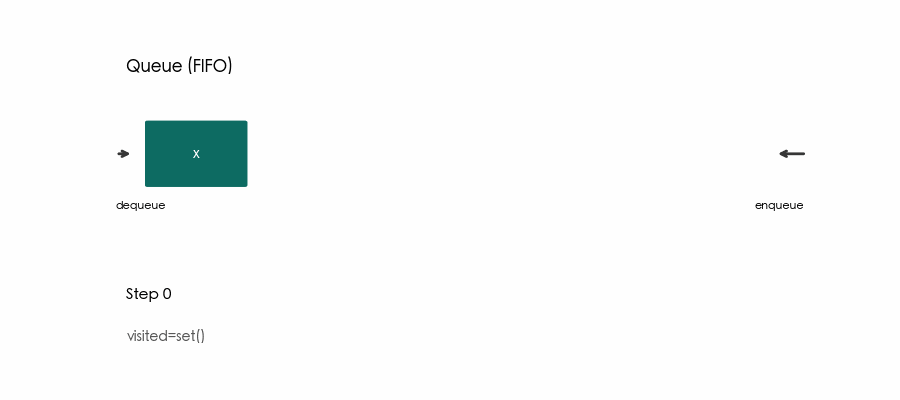

In [14]:
animate_bfs_queue()

In [15]:
display(trace_search('bfs'))

,步,弹出,g,h,frontier,visited,到达?
0,1,x,0,7,∅,x,False
1,2,c2,7,1,j→s1,c2→x,False
2,3,j,2,4,s1,c2→j→x,False
3,4,s1,2,3,s2,c2→j→s1→x,False
4,5,s2,6,4,c1→t,c2→j→s1→s2→x,False
5,6,c1,8,0,t,c1→c2→j→s1→s2→x,True


In [16]:
path_bfs = run_all()['bfs']['path']

In [17]:
print('path:', '->'.join(path_bfs), ' cost:', path_cost(path_bfs, adj))

path: x->s1->c1  cost: 8


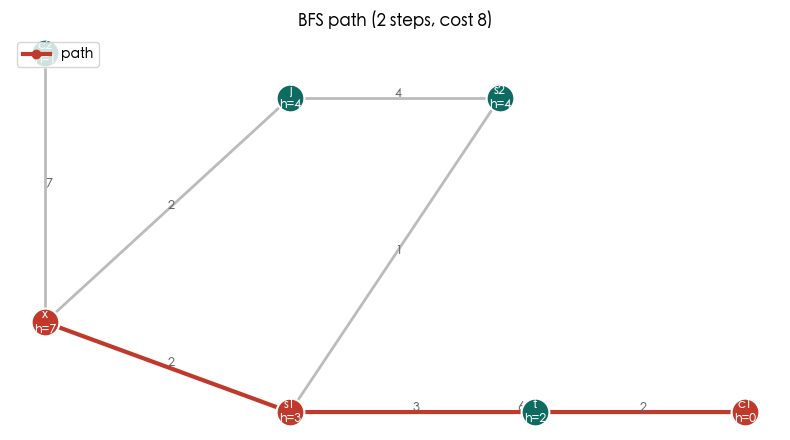

In [18]:
plot_campus(path_bfs, title='BFS path (2 steps, cost 8)')

**思考** · BFS 2 步但代价 8 不是最低——为什么？

<details><summary>查看答案</summary>

BFS 优化边数，不优化边权之和。

</details>

## 5. 深度优先 DFS

### 5.1 栈与回溯

LIFO 栈：栈顶出；本图先深入 j→s2→s1。

**DFS**

```text
while stack:
  u = stack.pop()
  push unvisited neighbors
```

In [19]:
dfs_frames = codelens_dfs()

In [20]:
print_codelens(dfs_frames)

── Step 0 ── DFS 初始化
   执行: stack=[start]
   stack = ['x']
   visited = set()

── Step 1 ── 栈顶弹出
   执行: current = stack.pop()  # x
   current = 'x'
   stack = []
   visited = {'x'}

── Step 1 ── 逆序入栈邻居 s1 (cost=2)
   执行: stack.append(s1)
   stack = ['s1']
   parent = {'s1': 'x'}

── Step 1 ── 逆序入栈邻居 j (cost=2)
   执行: stack.append(j)
   stack = ['s1', 'j']
   parent = {'s1': 'x', 'j': 'x'}

── Step 1 ── 逆序入栈邻居 c2 (cost=7)
   执行: stack.append(c2)
   stack = ['s1', 'j', 'c2']
   parent = {'s1': 'x', 'j': 'x', 'c2': 'x'}

── Step 2 ── 栈顶弹出
   执行: current = stack.pop()  # c2
   current = 'c2'
   stack = ['s1', 'j']
   visited = {'c2', 'x'}

── Step 3 ── 栈顶弹出
   执行: current = stack.pop()  # j
   current = 'j'
   stack = ['s1']
   visited = {'j', 'c2', 'x'}

── Step 3 ── 逆序入栈邻居 s2 (cost=4)
   执行: stack.append(s2)
   stack = ['s1', 's2']
   parent = {'s1': 'x', 'j': 'x', 'c2': 'x', 's2': 'j'}

── Step 4 ── 栈顶弹出
   执行: current = stack.pop()  # s2
   current = 's2'
   stack = ['s1']
   visited =

DFS: stack state at each step (GIF)


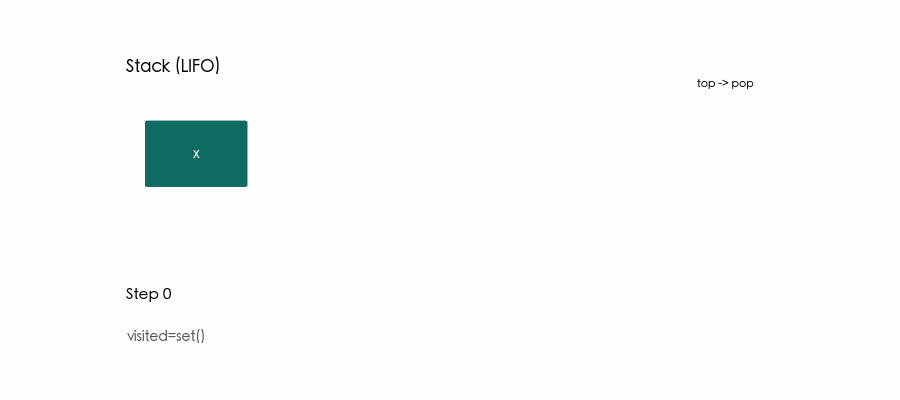

In [21]:
animate_dfs_stack()

In [22]:
display(trace_search('dfs'))

,步,弹出,g,h,frontier,visited,到达?
0,1,x,0,7,∅,x,False
1,2,c2,7,1,s1→j,c2→x,False
2,3,j,2,4,s1,c2→j→x,False
3,4,s2,6,4,s1,c2→j→s2→x,False
4,5,s1,2,3,∅,c2→j→s1→s2→x,False
5,6,c1,8,0,t,c1→c2→j→s1→s2→x,True


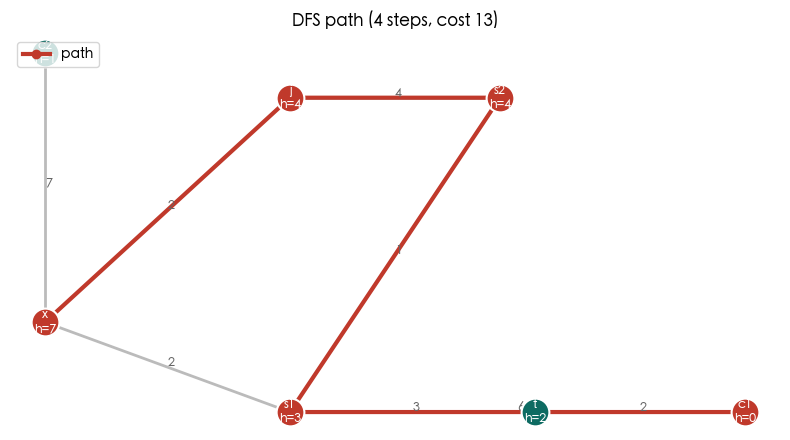

In [23]:
plot_campus(run_all()['dfs']['path'], title='DFS path (4 steps, cost 13)')

**思考** · DFS 路径是否最优？

<details><summary>查看答案</summary>

否，本例 4 步代价 13，非最低。

</details>

## 6. 一致代价 UCS

优先队列按 **g(n)** 累计代价排序。本例最优 x→s1→t→c1，代价 7。

**UCS**

```text
frontier = PriorityQueue by g(n)
```

In [24]:
display(trace_search('ucs'))

,步,弹出,g,h,frontier,visited,到达?
0,1,x,0,7,∅,x,False
1,2,j,2,4,s1→c2,j→x,False
2,3,s1,2,3,s2→c2,j→s1→x,False
3,4,s2,3,4,t→c2→c1,j→s1→s2→x,False
4,5,t,5,2,c2→c1,j→s1→s2→t→x,False
5,6,c1,7,0,c2,c1→j→s1→s2→t→x,True


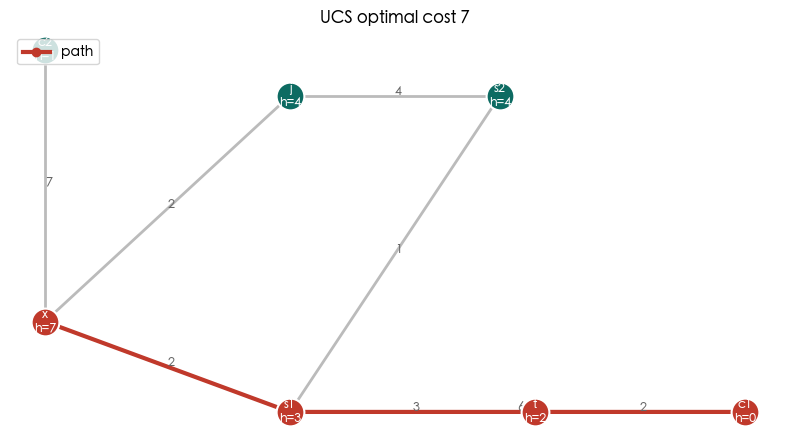

In [25]:
plot_campus(run_all()['ucs']['path'], title='UCS optimal cost 7')

**思考** · UCS 与 BFS 路径差异？

<details><summary>查看答案</summary>

UCS 代价 7 更优；BFS 步数更少但代价 8。

</details>

## 7. Greedy 与 A*

Greedy 按 h；A* 按 f=g+h。从 x：c2 的 f=8，s1 的 f=5，故先展开 s1。

In [26]:
display(first_step_scores())

,邻居,g,h,f=g+h,名称
2,s1,2,3,5,食堂
1,j,2,4,6,教学楼
0,c2,7,1,8,超市


In [27]:
display(trace_search('greedy'))

,步,弹出,g,h,frontier,visited,到达?
0,1,x,0,7,∅,x,False
1,2,c2,7,1,s1→j,c2→x,False
2,3,s1,2,3,j,c2→s1→x,False
3,4,c1,8,0,t→j→s2,c1→c2→s1→x,True


In [28]:
display(trace_search('astar'))

,步,弹出,g,h,frontier,visited,到达?
0,1,x,0,7,∅,x,False
1,2,s1,2,3,j→c2,s1→x,False
2,3,j,2,4,t→s2→c1→c2,j→s1→x,False
3,4,t,5,2,s2→c1→c2,j→s1→t→x,False
4,5,c1,7,0,s2→c2,c1→j→s1→t→x,True


**思考** · A* 在本图是否最优？

<details><summary>查看答案</summary>

是，与 UCS 同路径代价 7。

</details>

## 8. 五种算法对照

In [29]:
display(comparison_table())

,算法,路径,步数,代价,与网页
0,DFS,x→j→s2→s1→c1,4,13,✓
1,BFS,x→s1→c1,2,8,✓
2,UCS,x→s1→t→c1,3,7,✓
3,Greedy,x→s1→c1,2,8,✓
4,A*,x→s1→t→c1,3,7,✓


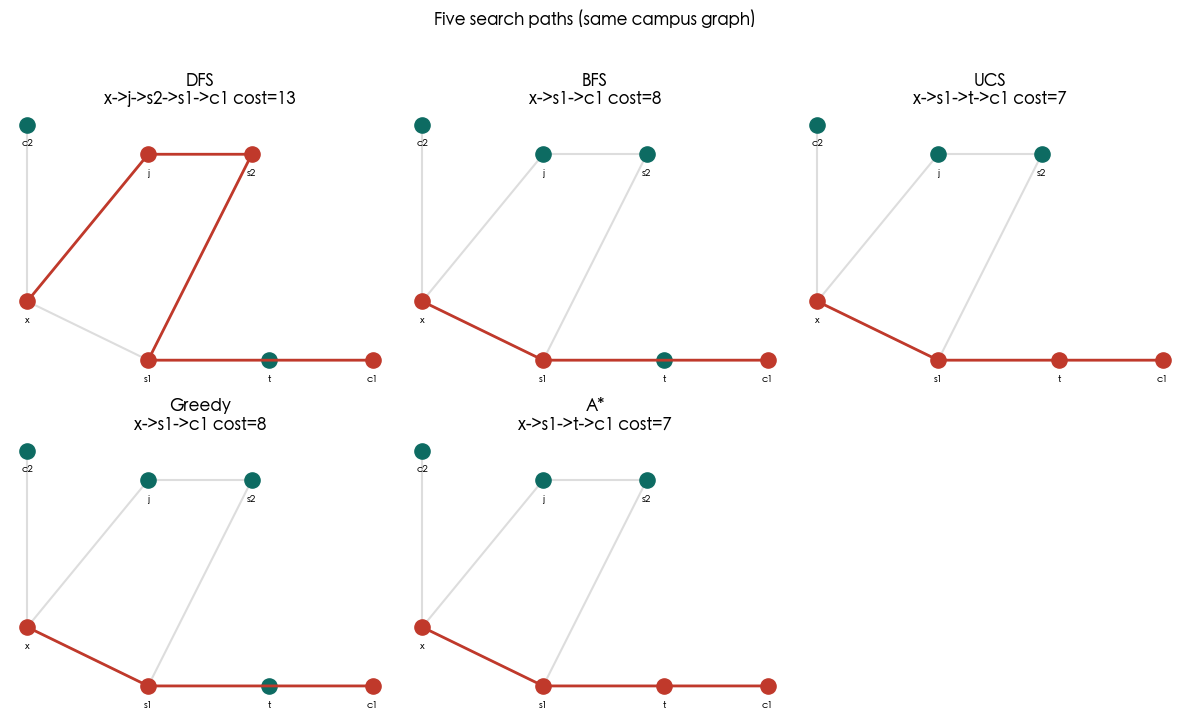

In [30]:
plot_all_paths()

In [31]:
verify_against_web()

✓ 五种算法路径与 ch5.html 完全一致


## 小结

BFS 队列保证最少步数；DFS 栈不保证最优；UCS/A* 在加权图上求最低代价。

对照 [ch5.html](../ch5.html) 步进动画验证每一步预测。

## 练习

1. 若所有边权为 1，BFS 与 UCS 路径是否相同？
2. 改变 DFS 入栈顺序，路径如何变化？